##**Python for Data Analysis – Final Project**

*Neste projeto será realizada a limpeza, análise e visualização dos dados de vendas de uma empresa que atua no mercado global. O objetivo é identificar padrões de vendas, lucro e desempenho por categoria, país, região e canal de vendas, gerando insights que possam apoiar decisões de negócio.*

***Conjunto de dados***

*O projeto utiliza três tabelas:*

*events.csv: informações sobre os pedidos realizados.*

*products.csv: relação entre os produtos e suas categorias.*

*countries.csv: informações sobre países, regiões e sub-regiões.*

###**1. Visão Geral dos Dados**

*1.1 Importação das Bibliotecas e Conexão com o Google Drive*

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


*1.2 Extração do conjunto de dados*

In [2]:
import zipfile

zip_path = '/content/drive/MyDrive/Mate_homework/dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/final_project')

*1.3 Carregamento dos arquivos*

In [3]:

import pandas as pd

events = pd.read_csv('/content/final_project/13. Final project/events.csv')

products = pd.read_csv('/content/final_project/13. Final project/products.csv')

countries = pd.read_csv('/content/final_project/13. Final project/countries.csv')



*1.4 Visão geral das tabelas*



In [4]:
events.info()
products.info()
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
mem

*1.5 Primeiras linhas das tabelas*

In [10]:
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [11]:
products.head()


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [12]:
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


*1.6 Valores Ausentes*

In [13]:
events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


In [14]:
products.isna().sum()

,0
id,0
item_type,0


In [15]:
countries.isna().sum()

,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


*Ao verificar os valores ausentes, identifiquei que a tabela events possui 82 registros sem código de país e 2 registros sem informação de quantidade vendida. A tabela products não apresentou valores ausentes. Já a tabela countries apresentou poucos registros com informações faltantes nas colunas alpha-2, region e sub-region.*

*Como estratégia de tratamento, os registros sem Units Sold serão removidos, pois essa informação é essencial para os cálculos de vendas. Já os valores ausentes relacionados às informações geográficas serão preenchidos como "Unknown", preservando os registros para as análises posteriores.*

###**2.Limpeza dos Dados**

*2.1 Identificação dos valores ausentes*

In [17]:
countries[countries.isna().any(axis=1)]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


*Ao analisar os registros com valores ausentes na tabela countries, foram identificados apenas dois casos: Antártica, sem informações de região e sub-região, e Namíbia, sem o código alpha-2.*

*Como representam uma pequena quantidade de registros, os valores ausentes serão preenchidos como "Unknown", preservando as informações disponíveis e evitando perda de dados.*

*2.2 Tratamento dos valores ausentes em Units Sold*

In [18]:
events[events["Units Sold"].isna()]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
183,217165648,5/20/2014,6/8/2014,M,ESP,8875,Offline,NaN,421.89,364.69
319,309655511,5/5/2014,5/21/2014,C,HRV,3127,Offline,NaN,81.73,56.67


In [19]:
events = events.dropna(subset=["Units Sold"])

In [20]:
events["Units Sold"].isna().sum()

np.int64(0)

In [21]:
events.shape

(1328, 10)

In [22]:
events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


*Os dois registros com valores ausentes na coluna Units Sold foram removidos, pois essa informação é essencial para os cálculos de vendas, receita e lucro. Como esses registros representam uma parcela muito pequena do conjunto de dados, sua exclusão não compromete a análise e evita possíveis distorções nos resultados. Após o tratamento, foi realizada uma nova verificação confirmando que não existem mais valores ausentes nessa coluna.*

*2.3 Tratamento dos valores ausentes em Country Code*

In [23]:
events[events["Country Code"].isna()]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
13,104548490,1/1/2014,1/5/2014,M,NaN,7331,Online,7076.0,255.28,159.42
26,117929494,1/24/2015,3/2/2015,H,NaN,4594,Offline,6813.0,9.33,6.92
29,118859469,6/2/2011,7/1/2011,L,NaN,8969,Offline,2013.0,152.58,97.44
43,126948583,5/24/2017,7/9/2017,C,NaN,7331,Online,5762.0,255.28,159.42
...,...,...,...,...,...,...,...,...,...,...
1213,919922006,8/27/2011,9/18/2011,L,NaN,4594,Online,4219.0,9.33,6.92
1220,922564303,3/17/2017,4/2/2017,L,NaN,7940,Offline,6134.0,668.27,502.54
1250,941061675,3/8/2017,3/20/2017,M,NaN,5988,Offline,9917.0,154.06,90.93
1296,975080668,7/23/2017,8/20/2017,C,NaN,5988,Offline,6893.0,154.06,90.93


In [24]:
events["Country Code"] = events["Country Code"].fillna("Unknown")

In [25]:
events["Country Code"].isna().sum()

np.int64(0)

*Os registros com valores ausentes na coluna Country Code foram analisados e preenchidos com o valor "Unknown". Essa decisão foi tomada para preservar os dados de vendas, evitando a remoção de registros que ainda possuem informações relevantes, como quantidade vendida, receita e lucro.*

*Como esses registros não possuem identificação do país, eles poderão ser desconsiderados apenas nas análises geográficas que dependem dessa informação.*

*2.3.1 Tratamento dos valores ausentes em countries*

In [26]:
countries[countries.isna().any(axis=1)]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


In [28]:
countries = countries.fillna("Unknown")

In [27]:
countries.isna().sum()

,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


*Os valores ausentes identificados na tabela countries foram preenchidos como "Unknown". Como os registros afetados representam uma pequena quantidade do conjunto de dados, essa decisão permite preservar as informações existentes e evitar perda de registros durante as análises geográficas.*

*2.4 Conversão dos tipos de dados*

In [29]:
events.dtypes

,0
Order ID,int64
Order Date,object
Ship Date,object
Order Priority,object
Country Code,object
Product ID,int64
Sales Channel,object
Units Sold,float64
Unit Price,float64
Unit Cost,float64


In [30]:

events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

In [31]:
events.dtypes

,0
Order ID,int64
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Order Priority,object
Country Code,object
Product ID,int64
Sales Channel,object
Units Sold,float64
Unit Price,float64
Unit Cost,float64


*Verifiquei os tipos de dados da tabela events e identifiquei que as colunas Order Date e Ship Date estavam como texto (object).* *Como representam datas, realizei a conversão para o tipo datetime, permitindo realizar análises temporais de forma mais precisa.*

*2.5 Verificação de duplicatas*

In [32]:
events.duplicated().sum()

np.int64(0)

In [33]:
products.duplicated().sum()

np.int64(0)

In [34]:
countries.duplicated().sum()

np.int64(0)

*Verifiquei a existência de registros duplicados nas três tabelas e não foram encontradas duplicatas completas.*
*Dessa forma, não foi necessário remover nenhum registro nessa etapa da limpeza dos dados.*

*2.6 – Análise de anomalias*

In [35]:
events["Sales Channel"].value_counts()

,count
Sales Channel,
Offline,665
Online,660
online,3


In [36]:
events["Sales Channel"] = (
    events["Sales Channel"]
    .str.strip()
    .str.title()
)

In [37]:
events["Sales Channel"].value_counts()

,count
Sales Channel,
Offline,665
Online,663


In [38]:
events["Order Priority"].value_counts()

,count
Order Priority,
M,352
H,335
L,334
C,304
C,2
M,1


In [39]:
events["Order Priority"] = (
    events["Order Priority"]
    .str.strip()
    .str.upper()
)

In [40]:
events["Order Priority"].value_counts()

,count
Order Priority,
M,353
H,335
L,334
C,306


*Durante a análise das variáveis categóricas, foram identificadas inconsistências de padronização nas colunas Sales Channel e Order Priority.*

*Na coluna Sales Channel, alguns registros apresentavam diferença no uso de letras maiúsculas e minúsculas, fazendo com que valores equivalentes fossem interpretados como categorias diferentes.*

*Já na coluna Order Priority, foram encontrados registros com espaços extras antes ou depois dos valores.*

*Para corrigir essas inconsistências, os textos foram padronizados removendo espaços desnecessários e ajustando o formato das categorias, garantindo maior consistência para as próximas etapas da análise.*

*2.6.1 Verificação da quantidade de unidades vendidas*

In [41]:
events[events["Units Sold"] <= 0]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost



*Verifiquei a coluna Units Sold em busca de valores menores ou iguais a zero e não foram encontradas anomalias.* *Isso indica que as quantidades vendidas estão consistentes para a análise.*

*2.6.2 Verificação dos preços*

In [42]:
events[(events["Unit Price"] <= 0) | (events["Unit Cost"] <= 0)]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


*Verifiquei as colunas Unit Price e Unit Cost em busca de valores menores ou iguais a zero e não foram identificadas anomalias.* *Os preços e custos registrados são válidos para a análise.*

*2.6.3 Verificação das datas*

In [43]:
events[events["Ship Date"] < events["Order Date"]]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


*Verifiquei se havia pedidos com data de envio anterior à data do pedido e não foram encontradas inconsistências.*

*Conclusão geral da análise de anomalias*

*Após analisar os dados, foram corrigidas inconsistências de padronização em variáveis categóricas, como diferenças de maiúsculas/minúsculas e espaços extras nos textos.
Também foram verificadas possíveis anomalias relacionadas à quantidade vendida, preços e datas dos pedidos, não sendo encontrados valores inconsistentes nessas variáveis.
Após os tratamentos realizados, os dados apresentam maior consistência e estão preparados para as próximas etapas de análise e visualização.*

###**3. Análise e Visualização dos Dados**

*3.1 Unir as três tabelas em um único DataFrame*

In [6]:
df = events.merge(
    products,
    left_on="Product ID",
    right_on="id",
    how="left"
)

df = df.merge(
    countries,
    left_on="Country Code",
    right_on="alpha-3",
    how="left"
)

df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54,7940,Household,NaN,NaN,NaN,NaN,NaN
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe


*Uni as três tabelas em um único DataFrame, combinando os dados de pedidos, categorias de produtos e informações geográficas.* *Com isso, o conjunto de dados ficou pronto para as próximas análises de vendas, lucro, países, regiões e canais.*

*3.2 Remover colunas desnecessárias e renomear colunas*

In [44]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Order Priority', 'Country Code',
       'Product ID', 'Sales Channel', 'Units Sold', 'Unit Price', 'Unit Cost',
       'id', 'item_type', 'name', 'alpha-2', 'alpha-3', 'region',
       'sub-region'],
      dtype='object')

In [45]:
df = df.drop(
    columns=[
        "id",
        "alpha-2",
        "alpha-3"
    ],
    errors="ignore"
)

df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Order Priority', 'Country Code',
       'Product ID', 'Sales Channel', 'Units Sold', 'Unit Price', 'Unit Cost',
       'item_type', 'name', 'region', 'sub-region'],
      dtype='object')

*Após a união das tabelas, removi as colunas id, alpha-2 e alpha-3, pois continham informações duplicadas ou que não seriam utilizadas nas análises.* *Dessa forma, o DataFrame ficou mais organizado e preparado para as próximas etapas do projeto.*

*3.3 Métricas-chave da empresa (KPIs)*

In [47]:
df["Revenue"] = df["Units Sold"] * df["Unit Price"]

df["Cost"] = df["Units Sold"] * df["Unit Cost"]

df["Profit"] = df["Units Sold"] * (df["Unit Price"] - df["Unit Cost"])

df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,item_type,name,region,sub-region,Revenue,Cost,Profit
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54,Household,NaN,NaN,NaN,3136191.11,2358420.22,777770.89
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68


*Criei as colunas Revenue, Cost e Profit, que representam respectivamente a receita, o custo e o lucro de cada pedido. Essas métricas serão utilizadas nas próximas análises e visualizações do projeto para avaliar o desempenho financeiro da empresa.*

In [48]:
total_orders = df["Order ID"].nunique()

total_revenue = df["Revenue"].sum()

total_profit = df["Profit"].sum()

total_countries = df["Country Code"].nunique()

total_categories = df["item_type"].nunique()

total_units = df["Units Sold"].sum()

print("Total de pedidos:", total_orders)
print("Receita total:", total_revenue)
print("Lucro total:", total_profit)
print("Países atendidos:", total_countries)
print("Categorias de produtos:", total_categories)
print("Total de unidades vendidas:", total_units)


print(f"Receita total: ${total_revenue:,.2f}")
print(f"Lucro total: ${total_profit:,.2f}")

Total de pedidos: 1330
Receita total: 1702129408.21
Lucro total: 501434459.0
Países atendidos: 45
Categorias de produtos: 12
Total de unidades vendidas: 6576524.0
Receita total: $1,702,129,408.21
Lucro total: $501,434,459.00


*As métricas mostram que a empresa realizou 1.328 pedidos, gerando uma receita superior a 1,7 bilhão e um lucro de aproximadamente 501 milhões. As vendas abrangeram 46 países e 12 categorias de produtos, totalizando mais de 6,5 milhões de unidades vendidas. Esses indicadores fornecem uma visão geral do desempenho da empresa e servirão como base para as próximas análises.*

*3.4 Análise das vendas por categoria de produto*

*3.4.1 Receita por categoria de produto*

In [49]:

sales_category = (
    df.groupby("item_type")["Revenue"]
      .sum()
      .sort_values(ascending=True)
)

sales_category

,Revenue
item_type,
Fruits,5.520300e+06
Beverages,2.909316e+07
Personal Care,4.557902e+07
Clothes,6.462655e+07
Snacks,7.478861e+07
Vegetables,8.974673e+07
Cereal,9.579140e+07
Baby Food,1.436476e+08
Meat,2.237620e+08


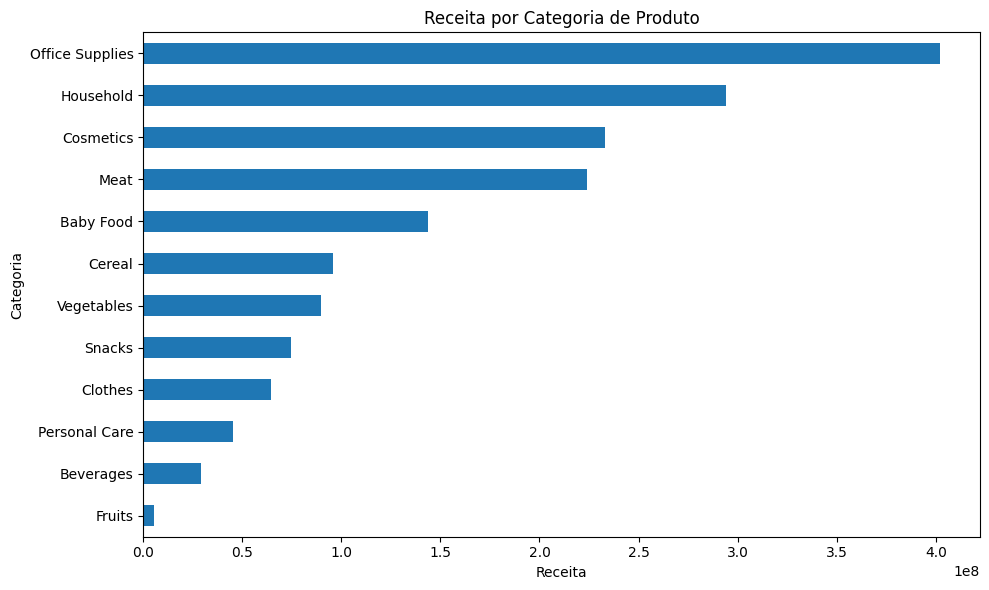

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sales_category.plot(kind="barh")

plt.title("Receita por Categoria de Produto")
plt.xlabel("Receita")
plt.ylabel("Categoria")

plt.tight_layout()

plt.show()

*Ao analisar a receita por categoria, observei que Office Supplies foi a categoria com maior faturamento, seguida por Household e Cosmetics. Já Fruits apresentou a menor receita. Isso mostra que algumas categorias concentram grande parte do faturamento da empresa.*

*3.4.2 Custo por categoria de produto*

In [52]:
cost_category = (
    df.groupby("item_type")["Cost"]
      .sum()
      .sort_values(ascending=True)
)

cost_category


,Cost
item_type,
Fruits,4.094370e+06
Beverages,1.949150e+07
Clothes,2.119524e+07
Personal Care,3.160361e+07
Snacks,4.776119e+07
Vegetables,5.297073e+07
Cereal,5.453637e+07
Baby Food,8.970659e+07
Cosmetics,1.404315e+08


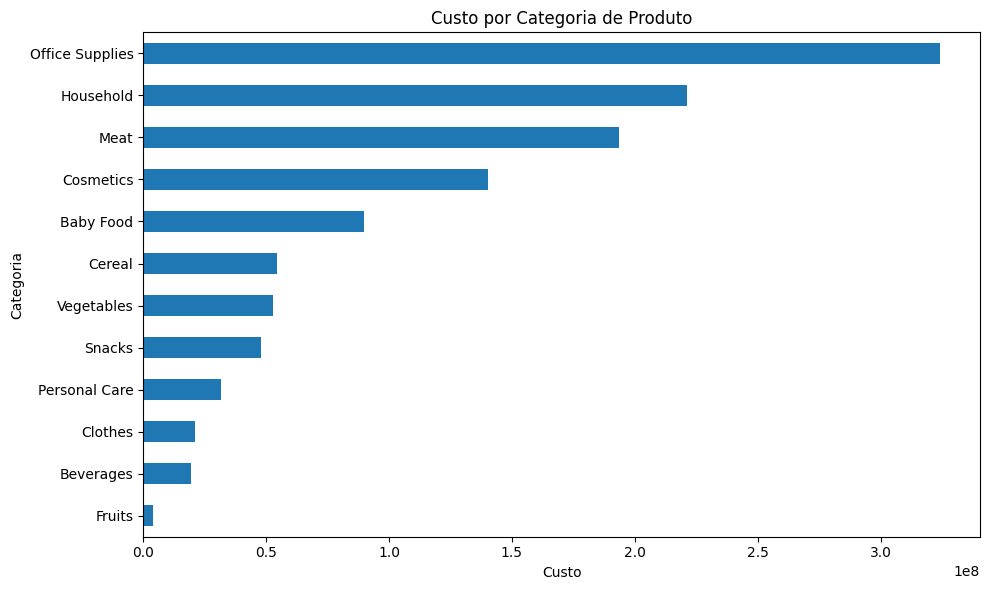

In [53]:


import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

cost_category.plot(kind="barh")

plt.title("Custo por Categoria de Produto")
plt.xlabel("Custo")
plt.ylabel("Categoria")

plt.tight_layout()

plt.show()

*Ao analisar os custos por categoria, observei que Office Supplies apresentou o maior custo total, seguida por Household e Meat. Já a categoria Fruits teve o menor custo. Esses resultados mostram quais categorias representam a maior parte das despesas da empresa.*

*3.4.3 Lucro por categoria de produto*

In [54]:
profit_category = (
    df.groupby("item_type")["Profit"]
      .sum()
      .sort_values(ascending=True)
)

profit_category

,Profit
item_type,
Fruits,1425929.52
Beverages,9601662.78
Personal Care,13975410.68
Snacks,27027422.40
Meat,30337736.00
Vegetables,36776002.72
Cereal,41255034.15
Clothes,43431314.40
Baby Food,53940997.16


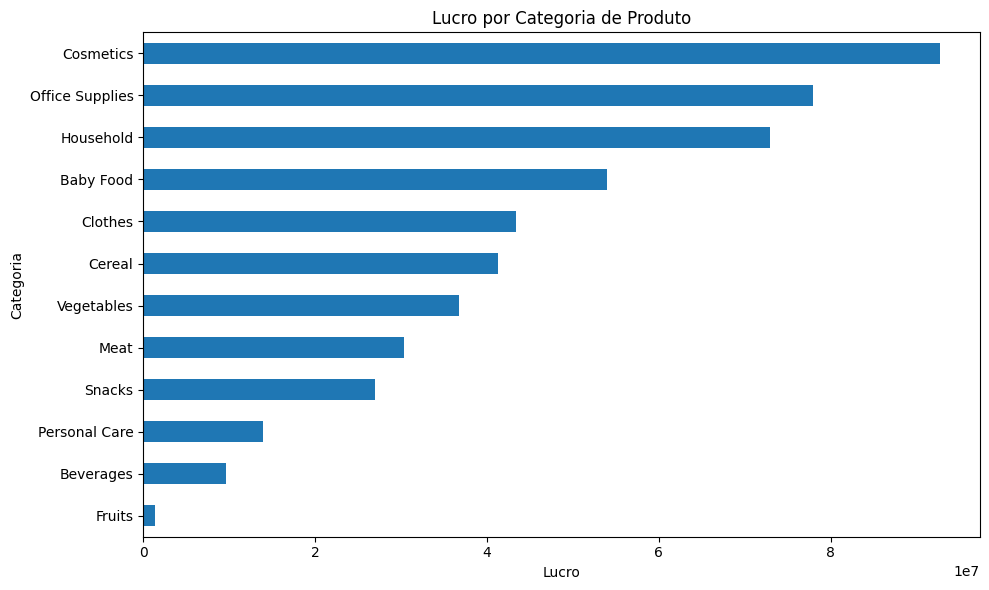

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

profit_category.plot(kind="barh")

plt.title("Lucro por Categoria de Produto")
plt.xlabel("Lucro")
plt.ylabel("Categoria")

plt.tight_layout()

plt.show()

*Ao analisar o lucro por categoria, observei que Cosmetics apresentou o maior lucro, seguida por Office Supplies e Household. Já a categoria Fruits foi a que gerou o menor lucro. Isso mostra que uma categoria com alta receita nem sempre é a mais lucrativa, reforçando a importância de analisar também os custos.*

*3.4.4 Popularidade dos produtos (Quantidade vendida)*

In [56]:
units_category = (
    df.groupby("item_type")["Units Sold"]
      .sum()
      .sort_values(ascending=True)
)

units_category

,Units Sold
item_type,
Household,440249.0
Cereal,465685.0
Snacks,490160.0
Meat,530380.0
Cosmetics,533291.0
Personal Care,557678.0
Baby Food,562706.0
Vegetables,582544.0
Clothes,591385.0


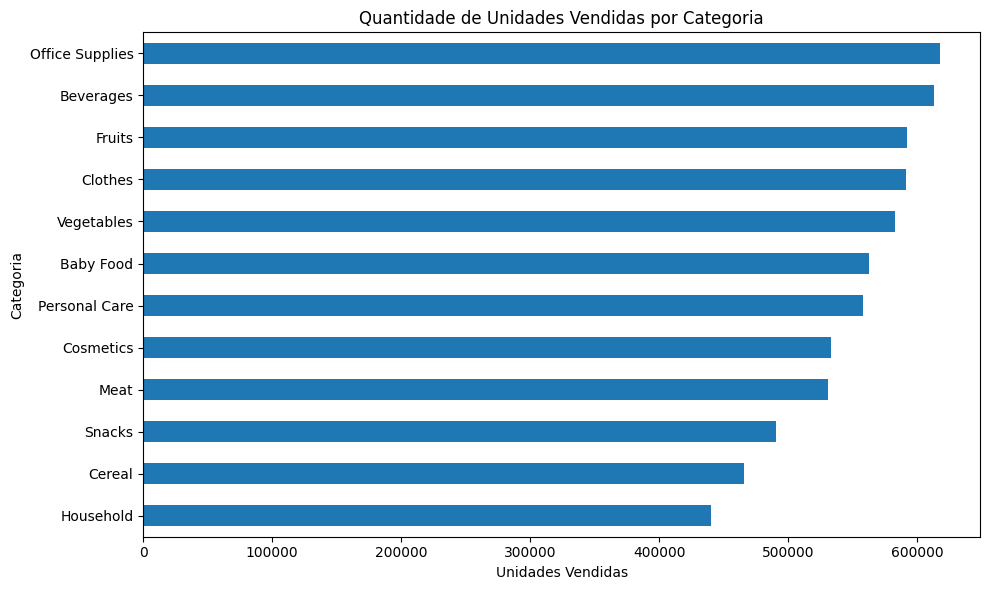

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

units_category.plot(kind="barh")

plt.title("Quantidade de Unidades Vendidas por Categoria")
plt.xlabel("Unidades Vendidas")
plt.ylabel("Categoria")

plt.tight_layout()

plt.show()

*Ao analisar a quantidade de unidades vendidas, observei que Office Supplies foi a categoria com maior volume de vendas, seguida por Beverages e Fruits. Já Household apresentou a menor quantidade de unidades vendidas entre as categorias analisadas.*

*Conclusão da análise por categoria*

*A análise por categoria mostrou diferenças importantes entre faturamento, custos, lucro e quantidade vendida. A categoria Office Supplies apresentou a maior receita, o maior custo e também o maior volume de unidades vendidas. Já Cosmetics foi a categoria com maior lucro, indicando uma margem mais elevada. Esses resultados mostram que vender mais nem sempre significa gerar mais lucro, reforçando a importância de analisar os indicadores em conjunto para apoiar a tomada de decisão.*

*3.5 Analise geográfica*

*3.5.1 Receita por país*

In [58]:
sales_country = (
    df.groupby("name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

sales_country.head(10)

,Revenue
name,
Czech Republic,53543932.14
Ukraine,53252317.54
Bosnia and Herzegovina,50117508.49
Macedonia,49222085.25
San Marino,47883708.48
Andorra,47756693.17
Portugal,47172189.84
Malta,47145320.81
Russia,46051659.81


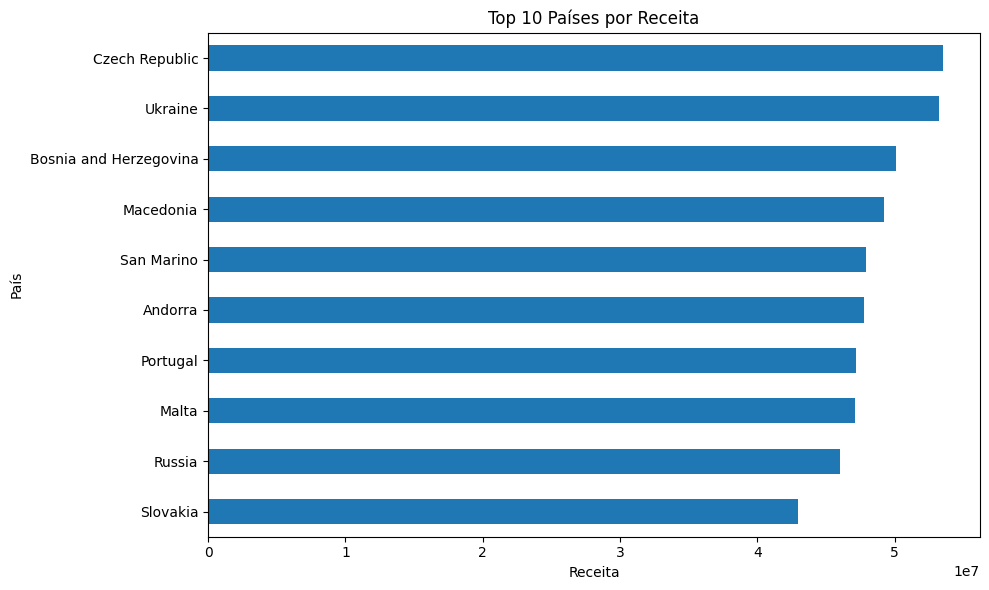

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sales_country.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Países por Receita")
plt.xlabel("Receita")
plt.ylabel("País")

plt.tight_layout()

plt.show()

*Ao analisar a receita por país, observei que a República Tcheca apresentou o maior faturamento, seguida pela Ucrânia e pela Bósnia e Herzegovina. Esses países concentraram as maiores receitas entre os mercados analisados, indicando forte participação nas vendas da empresa.*

*3.5.2 Custo por país*

In [60]:
cost_country = (
    df.dropna(subset=["name"])
      .groupby("name")["Cost"]
      .sum()
      .sort_values(ascending=False)
)

cost_country.head(10)

,Cost
name,
Czech Republic,39908338.36
Ukraine,38447391.80
Bosnia and Herzegovina,36859905.72
Portugal,35826782.25
Macedonia,35537985.30
San Marino,34090715.67
Russia,32783977.17
Malta,32535192.93
Andorra,32346656.54


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

cost_country.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Países por Custo")
plt.xlabel("Custo")
plt.ylabel("País")

plt.tight_layout()
plt.show()

*Ao analisar os custos por país, observei quais mercados concentraram as maiores despesas da empresa. Essa análise complementa a visão de receita e lucro, permitindo identificar se os países com maior faturamento também representam maiores custos operacionais.*

*3.5.3 Lucro por país*

In [61]:
profit_country = (
    df.groupby("name")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

profit_country.head(10)


,Profit
name,
Andorra,15410036.63
Ukraine,14804925.74
Malta,14610127.88
San Marino,13792992.81
Hungary,13786231.03
Macedonia,13684099.95
Czech Republic,13635593.78
Russia,13267682.64
Bosnia and Herzegovina,13257602.77


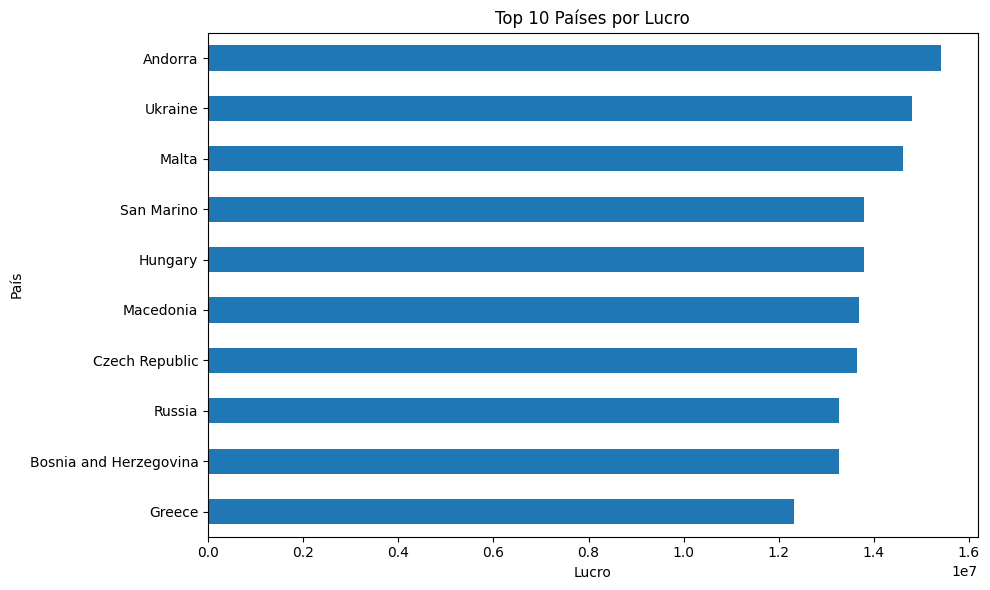

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

profit_country.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Países por Lucro")
plt.xlabel("Lucro")
plt.ylabel("País")

plt.tight_layout()

plt.show()

*Ao analisar o lucro por país, observei que Andorra apresentou o maior lucro, seguida pela Ucrânia e por Malta.
Embora alguns países também tenham se destacado em receita, a análise do lucro mostra que um faturamento elevado nem sempre representa o maior retorno financeiro, reforçando a importância de avaliar diferentes indicadores de desempenho.*

*3.5.4 Popularidade por país*

In [ ]:
units_country = (
    df.dropna(subset=["name"])
      .groupby("name")["Units Sold"]
      .sum()
      .sort_values(ascending=False)
)

units_country.head(10)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

units_country.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Países por Unidades Vendidas")
plt.xlabel("Unidades Vendidas")
plt.ylabel("País")

plt.tight_layout()

plt.show()

*Ao analisar a quantidade de unidades vendidas por país, foi possível identificar os mercados com maior volume de vendas. Essa métrica ajuda a complementar a análise financeira, pois um país pode ter alto volume de unidades vendidas, mas não necessariamente gerar a maior receita ou lucro.*

*3.5.5 Receita por Região*

In [63]:
sales_region = (
    df.dropna(subset=["region"])
      .groupby("region")["Revenue"]
      .sum()
      .sort_values(ascending=True)
)

sales_region


,Revenue
region,
Asia,9.333089e+07
Europe,1.505653e+09


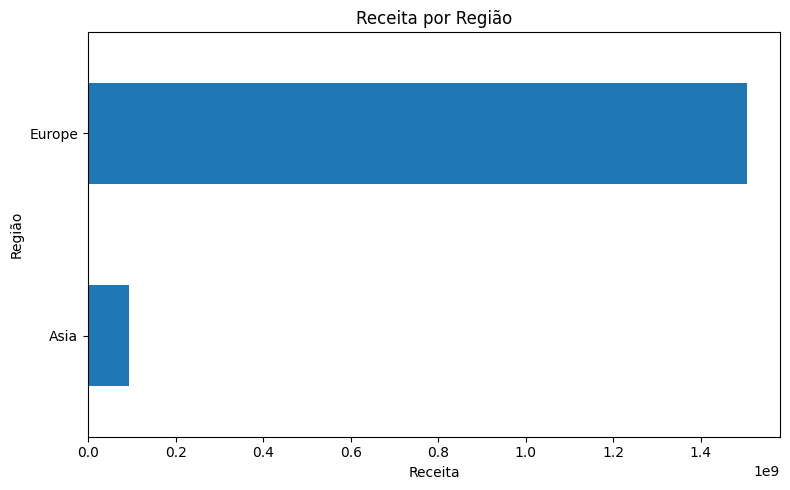

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sales_region.plot(kind="barh")

plt.title("Receita por Região")
plt.xlabel("Receita")
plt.ylabel("Região")

plt.tight_layout()

plt.show()

*Ao analisar a receita por região, observei que a Europa concentrou a maior parte do faturamento, enquanto a Ásia apresentou uma participação menor. Os registros sem informação de região não foram considerados nessa análise, pois não foi possível associá-los a um país específico.*

*3.5.6 Custo por região*

In [66]:
cost_region = (
    df.dropna(subset=["region"])
      .groupby("region")["Cost"]
      .sum()
      .sort_values(ascending=True)
)

cost_region

,Cost
region,
Asia,6.817863e+07
Europe,1.057096e+09


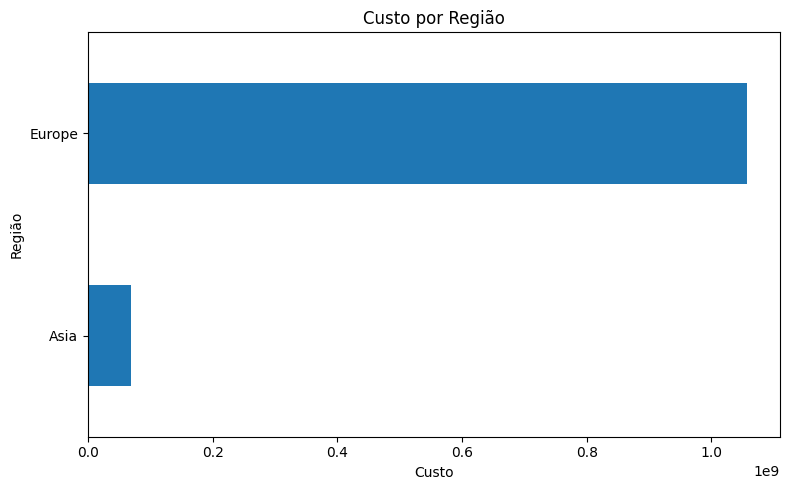

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

cost_region.plot(kind="barh")

plt.title("Custo por Região")
plt.xlabel("Custo")
plt.ylabel("Região")

plt.tight_layout()

plt.show()

*Ao analisar os custos por região, observei que a Europa concentrou a maior parte das despesas, enquanto a Ásia apresentou custos menores. Esse resultado acompanha a maior concentração de vendas e receita no mercado europeu.*

*3.5.7 Lucro por região*

In [78]:
profit_region = (
    df.dropna(subset=["region"])
      .groupby("region")["Profit"]
      .sum()
      .sort_values(ascending=True)
)

profit_region

,Profit
region,
Asia,2.515225e+07
Europe,4.485568e+08


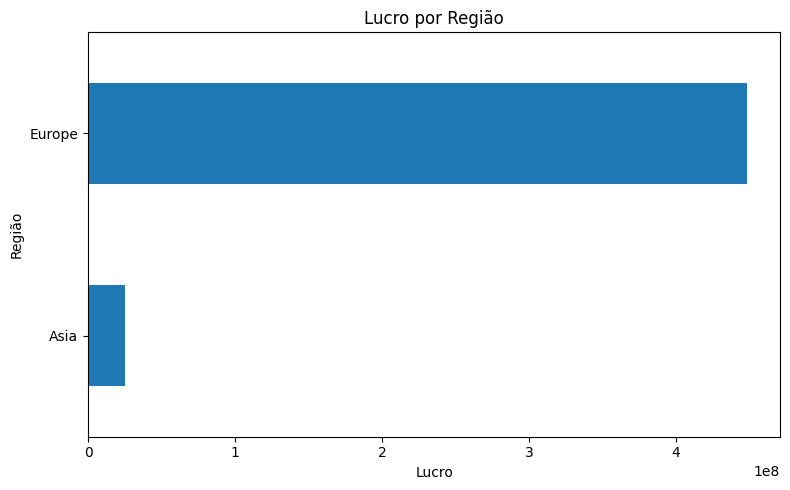

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

profit_region.plot(kind="barh")

plt.title("Lucro por Região")
plt.xlabel("Lucro")
plt.ylabel("Região")

plt.tight_layout()

plt.show()

*Ao analisar o lucro por região, observei que a Europa apresentou o maior lucro da empresa, enquanto a Ásia contribuiu com uma parcela menor. Assim como na análise de receita, os resultados indicam que a maior parte do desempenho financeiro está concentrada no mercado europeu.*

*3.5.8* Popularidade por região*

In [80]:
units_region = (
    df.dropna(subset=["region"])
      .groupby("region")["Units Sold"]
      .sum()
      .sort_values(ascending=True)
)

units_region

,Units Sold
region,
Asia,410427.0
Europe,5761244.0


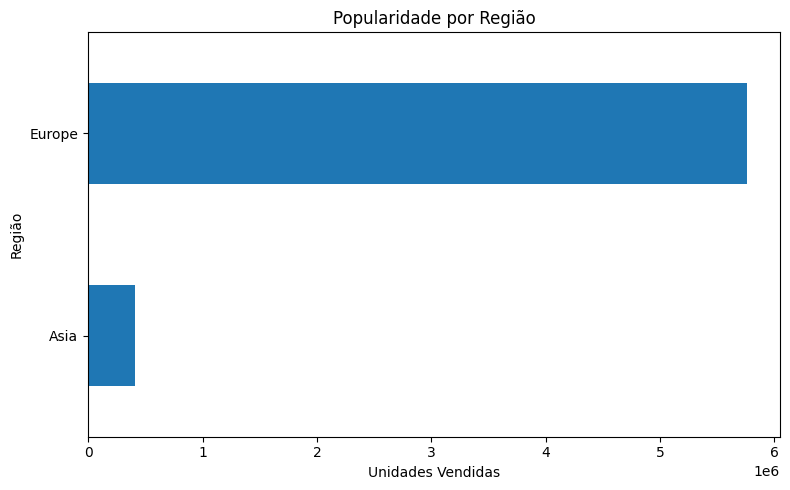

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

units_region.plot(kind="barh")

plt.title("Popularidade por Região")
plt.xlabel("Unidades Vendidas")
plt.ylabel("Região")

plt.tight_layout()

plt.show()

*Ao analisar a quantidade de unidades vendidas por região, observei que a Europa também concentrou o maior volume de vendas, enquanto a Ásia teve participação menor. Isso reforça a predominância do mercado europeu nos principais indicadores analisados.*

*Conclusão geral da análise geográfica*

*A análise geográfica mostrou que a Europa concentrou a maior parte da receita, custos, lucro e unidades vendidas da empresa, enquanto a Ásia apresentou uma participação menor. Além disso, foi possível identificar diferenças entre os países com maior faturamento, maior custo, maior lucro e maior volume de vendas, mostrando que mercados devem ser avaliados por diferentes indicadores. Os registros sem identificação de país foram mantidos na base de dados, mas não foram considerados nas análises geográficas por não ser possível associá-los a uma região.*

*3.6 Análise por Canal de Vendas (Online x Offline)*

*3.6.1 Receita por Canal de Vendas*

In [82]:
sales_channel = (
    df.groupby("Sales Channel")["Revenue"]
      .sum()
      .sort_values(ascending=True)
)

sales_channel

,Revenue
Sales Channel,
online,5.579514e+06
Online,8.247893e+08
Offline,8.717606e+08


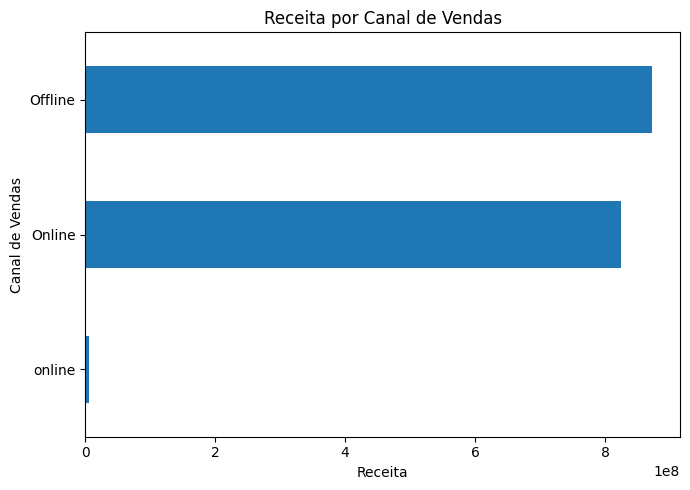

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sales_channel.plot(kind="barh")

plt.title("Receita por Canal de Vendas")
plt.xlabel("Receita")
plt.ylabel("Canal de Vendas")

plt.tight_layout()

plt.show()

*Ao analisar a receita por canal de vendas, observei que o canal Offline apresentou o maior faturamento, seguido pelo canal Online. Apesar da diferença não ser muito grande, as vendas presenciais geraram uma receita ligeiramente superior, indicando um desempenho um pouco melhor em relação ao canal online.*

*3.6.2 Custo por canal de vendas*

In [83]:
cost_channel = (
    df.groupby("Sales Channel")["Cost"]
      .sum()
      .sort_values(ascending=True)
)

cost_channel

,Cost
Sales Channel,
online,4.409421e+06
Online,5.779914e+08
Offline,6.182941e+08


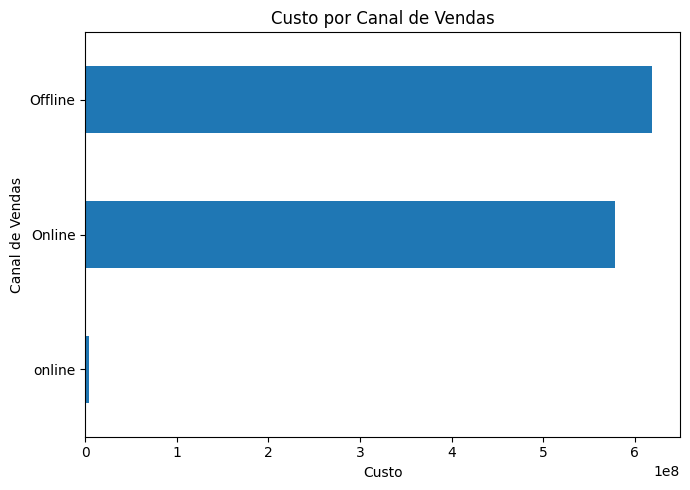

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

cost_channel.plot(kind="barh")

plt.title("Custo por Canal de Vendas")
plt.xlabel("Custo")
plt.ylabel("Canal de Vendas")

plt.tight_layout()

plt.show()

*Ao analisar os custos por canal de vendas, observei que o canal Offline apresentou o maior custo total. Esse resultado acompanha o maior volume de vendas registrado nesse canal, indicando que o aumento dos custos está relacionado ao maior faturamento.*

*3.6.3 Lucro por canal de vendas*

In [86]:
profit_channel = (
    df.groupby("Sales Channel")["Profit"]
      .sum()
      .sort_values(ascending=True)
)

profit_channel


,Profit
Sales Channel,
online,1.170094e+06
Online,2.467978e+08
Offline,2.534665e+08


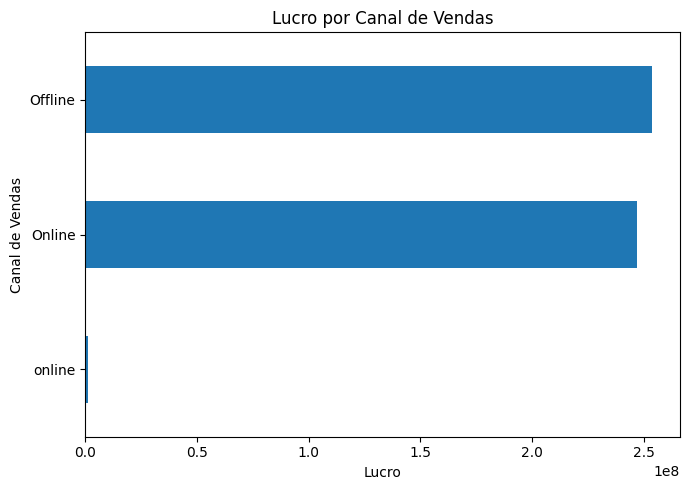

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

profit_channel.plot(kind="barh")

plt.title("Lucro por Canal de Vendas")
plt.xlabel("Lucro")
plt.ylabel("Canal de Vendas")

plt.tight_layout()

plt.show()

*Ao analisar o lucro por canal de vendas, observei que o canal Offline apresentou um lucro ligeiramente superior ao Online. Apesar da diferença ser pequena, o canal offline mostrou um desempenho financeiro um pouco melhor.*

*3.6.4 Quantidade de unidades vendidas por canal*

In [88]:
units_channel = (
    df.groupby("Sales Channel")["Units Sold"]
      .sum()
      .sort_values(ascending=True)
)

units_channel

,Units Sold
Sales Channel,
online,12925.0
Online,3243236.0
Offline,3320363.0


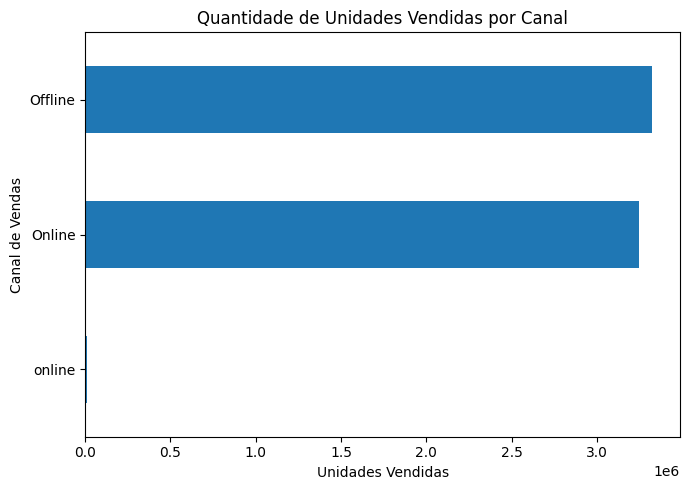

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

units_channel.plot(kind="barh")

plt.title("Quantidade de Unidades Vendidas por Canal")
plt.xlabel("Unidades Vendidas")
plt.ylabel("Canal de Vendas")

plt.tight_layout()

plt.show()

*Ao comparar a quantidade de unidades vendidas, observei que o canal Offline vendeu mais produtos do que o canal Online. Embora a diferença entre os dois canais seja pequena, as vendas presenciais apresentaram um volume ligeiramente maior.*

*Conclusão geral da Análise por Canal de Vendas (Online x Offline)*

*A análise por canal de vendas mostrou que os canais Online e Offline apresentaram resultados bastante próximos. No entanto, o canal Offline se destacou com valores ligeiramente superiores em receita, custo, lucro e quantidade de unidades vendidas. Esses resultados indicam que ambos os canais são importantes para o desempenho da empresa, mas o canal offline apresentou uma pequena vantagem no período analisado.*

*3.7 Análise do intervalo entre pedido e envio*

*3.7.1 Calcular o tempo de envio*

In [91]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [92]:
df["Shipping Time"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df[["Order Date", "Ship Date", "Shipping Time"]].head()

,Order Date,Ship Date,Shipping Time
0,2014-10-08,2014-10-18,10
1,2016-08-11,2016-08-11,0
2,2014-07-18,2014-08-11,24
3,2017-05-13,2017-06-13,31
4,2012-08-11,2012-09-18,38


*3.7.2 Tempo médio de envio*

In [93]:
average_shipping = df["Shipping Time"].mean()

print(f"Tempo médio de envio: {average_shipping:.2f} dias")

Tempo médio de envio: 24.78 dias


*O tempo médio entre a realização do pedido e o envio dos produtos foi de 24,78 dias. Esse indicador fornece uma visão geral da eficiência logística da empresa e servirá como base para comparar o desempenho entre categorias de produtos, países e regiões.*

*3.7.3 Tempo de envio por categoria*

In [94]:
shipping_category = (
    df.groupby("item_type")["Shipping Time"]
      .mean()
      .sort_values(ascending=True)
      .round(2)
)

shipping_category


,Shipping Time
item_type,
Personal Care,20.72
Clothes,23.10
Vegetables,23.49
Household,23.94
Beverages,24.12
Fruits,24.42
Snacks,25.54
Meat,25.85
Cosmetics,25.91


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

shipping_category.plot(kind="barh")

plt.title("Tempo Médio de Envio por Categoria de Produto")
plt.xlabel("Dias")
plt.ylabel("Categoria")

plt.tight_layout()

plt.show()

*Ao analisar o tempo médio de envio por categoria, observei que Personal Care apresentou o menor tempo médio de envio (20,72 dias), seguida por Clothes e Vegetables. Por outro lado, Cereal apresentou o maior tempo médio (27,18 dias), seguida por Office Supplies e Baby Food. Apesar dessas diferenças, os tempos médios de envio entre as categorias permaneceram relativamente próximos, variando entre aproximadamente 21 e 27 dias.*

*3.7.4 Tempo médio de envio por País*

In [95]:
shipping_country = (
    df.dropna(subset=["name"])
      .groupby("name")["Shipping Time"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
)

shipping_country.head(10)

,Shipping Time
name,
Hungary,32.64
Georgia,29.70
Austria,28.50
Slovakia,28.47
Luxembourg,27.75
Lithuania,27.56
Poland,27.46
Russia,27.38
Monaco,26.85


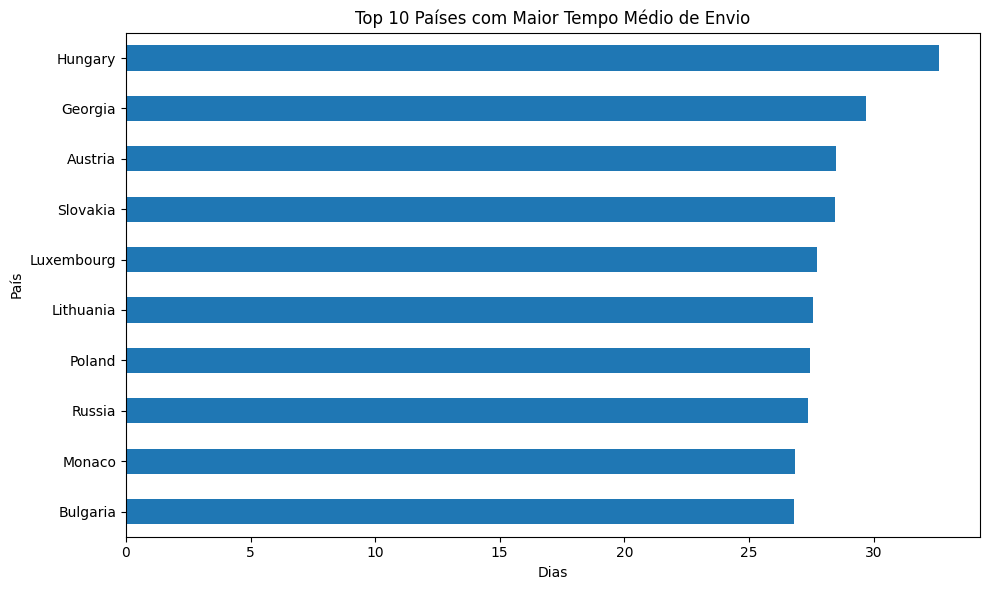

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

shipping_country.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Países com Maior Tempo Médio de Envio")
plt.xlabel("Dias")
plt.ylabel("País")

plt.tight_layout()

plt.show()

*Ao analisar o tempo médio de envio por país, observei que a Hungria apresentou o maior prazo médio (32,64 dias), seguida pela Geórgia (29,70 dias) e pela Áustria (28,50 dias). Os resultados mostram que alguns países apresentam tempos de envio superiores à média geral da empresa (24,78 dias), indicando possíveis diferenças logísticas entre os mercados atendidos.*

*3.7.5 Tempo médio de envio por Região*

In [97]:
shipping_region = (
    df.dropna(subset=["region"])
      .groupby("region")["Shipping Time"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
)

shipping_region

,Shipping Time
region,
Asia,26.09
Europe,24.78


*Ao analisar o tempo médio de envio por região, observei que a Ásia apresentou um prazo médio um pouco maior, enquanto a Europa teve um tempo médio ligeiramente menor. A diferença entre as regiões não é muito grande, mas indica que os pedidos da Ásia tendem a levar um pouco mais tempo entre a compra e o envio.*

*3.8 Relação entre lucro e tempo de envio*

*3.8.1 lucro × tempo de envio*

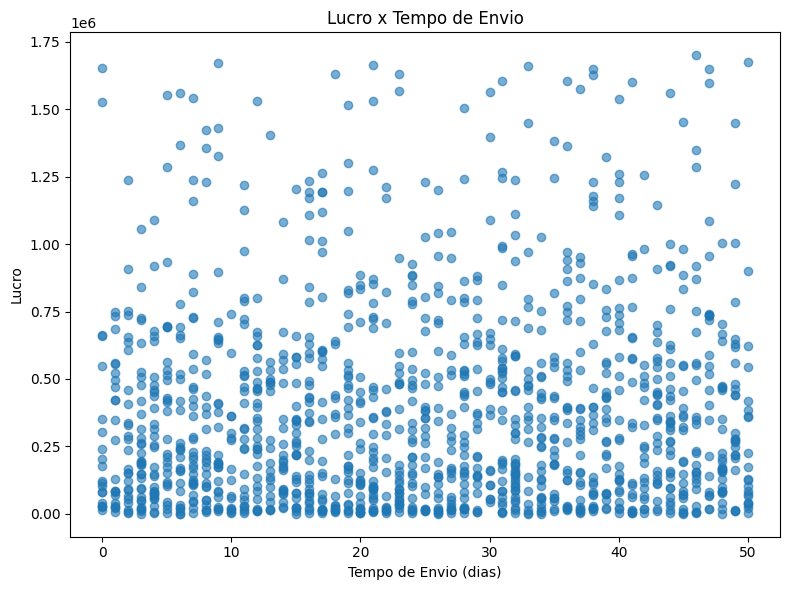

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["Shipping Time"], df["Profit"], alpha=0.6)

plt.title("Lucro x Tempo de Envio")
plt.xlabel("Tempo de Envio (dias)")
plt.ylabel("Lucro")

plt.tight_layout()
plt.show()

*Ao analisar a relação entre o tempo de envio e o lucro por meio do gráfico de dispersão, não foi possível identificar uma correlação evidente entre as duas variáveis. Os pedidos com maior e menor lucro estão distribuídos ao longo de diferentes tempos de envio, indicando que o prazo de envio, por si só, não parece influenciar diretamente a lucratividade da empresa.*

*3.9 Dinâmica das vendas ao longo do tempo*

In [99]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Year"] = df["Order Date"].dt.year

In [100]:
sales_year = (
    df.groupby("Year")["Revenue"]
      .sum()
)

sales_year

,Revenue
Year,
2010,2.093822e+08
2011,2.319376e+08
2012,2.854859e+08
2013,1.829624e+08
2014,2.362858e+08
2015,2.279541e+08
2016,1.915210e+08
2017,1.366005e+08


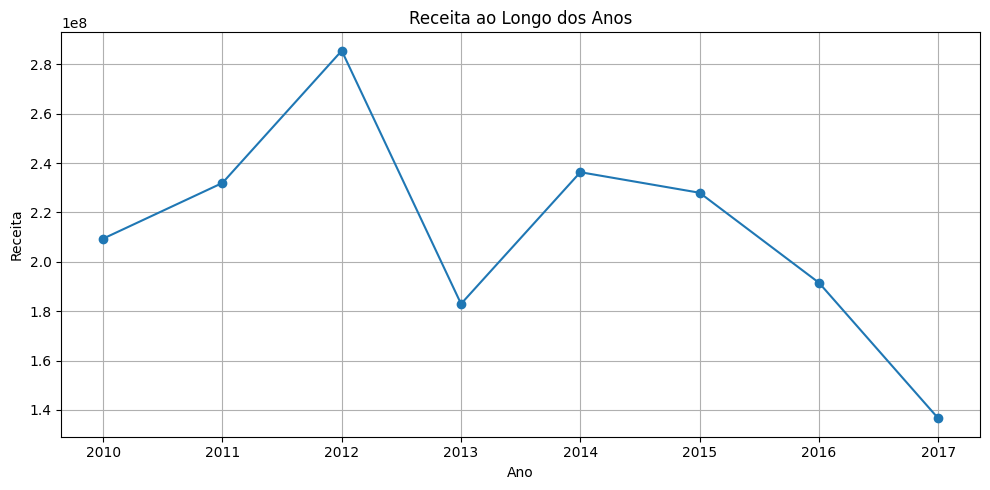

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sales_year.plot(kind="line", marker="o")

plt.title("Receita ao Longo dos Anos")
plt.xlabel("Ano")
plt.ylabel("Receita")

plt.grid(True)

plt.tight_layout()

plt.show()

*Ao analisar a evolução da receita ao longo dos anos, observei que as vendas cresceram entre 2010 e 2012, atingindo o maior faturamento em 2012. Após esse período, houve oscilações na receita, com recuperação em 2014, seguida por uma tendência de queda até 2017, que apresentou o menor faturamento do período analisado.*

*3.9.1 Dinâmica das vendas das 5 categorias com maior receita*

In [102]:
top5_categories = (
    df.groupby("item_type")["Revenue"]
      .sum()
      .nlargest(5)
      .index
)

top5_categories

Index(['Office Supplies', 'Household', 'Cosmetics', 'Meat', 'Baby Food'], dtype='object', name='item_type')

In [103]:
sales_category_year = (
    df[df["item_type"].isin(top5_categories)]
      .groupby(["Year", "item_type"])["Revenue"]
      .sum()
      .unstack()
)

sales_category_year

item_type,Baby Food,Cosmetics,Household,Meat,Office Supplies
Year,,,,,
2010,18351313.36,25620357.2,33551831.89,36099439.74,40776816.57
2011,14521092.24,39341879.2,30088188.48,30471005.25,58527498.75
2012,28261538.24,56664180.4,43688151.25,40162662.33,52324072.29
2013,18354887.28,14507607.6,29934486.38,25896873.87,40862125.08
2014,26004097.20,30832655.6,46085904.01,23268499.17,56529586.47
2015,19961109.04,20544902.4,46133351.18,28157782.38,75447888.18
2016,12321599.76,18402622.4,42542068.20,21259880.88,43534690.92
2017,5871950.56,27240620.4,22181217.84,18445874.58,34211317.35


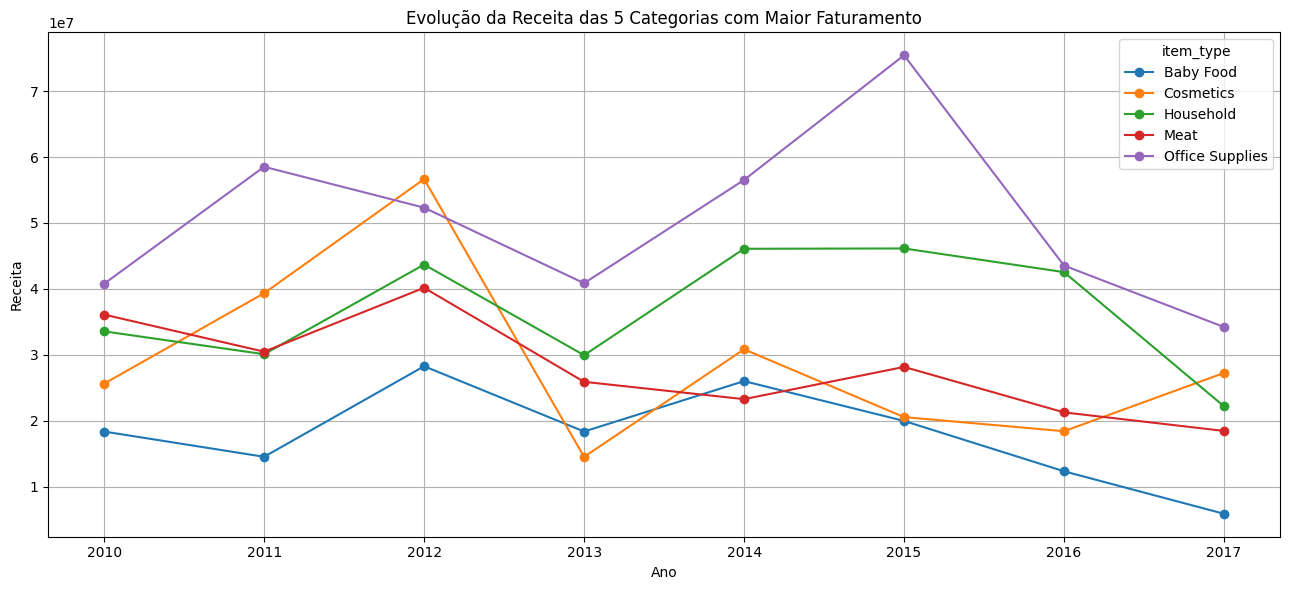

In [104]:
sales_category_year.plot(
    figsize=(13,6),
    marker="o"
)

plt.title("Evolução da Receita das 5 Categorias com Maior Faturamento")
plt.xlabel("Ano")
plt.ylabel("Receita")
plt.grid(True)

plt.tight_layout()
plt.show()

*Ao analisar a evolução da receita das cinco categorias com maior faturamento, observei que Office Supplies apresentou os maiores valores na maior parte do período, com destaque para o pico registrado em 2015. As categorias Household e Cosmetics também apresentaram receitas expressivas, porém com oscilações ao longo dos anos. De modo geral, todas as categorias analisadas apresentaram variações no faturamento, sem uma tendência contínua de crescimento ou queda durante todo o período.*

*3.9.2 Dinâmica das vendas por região*

In [105]:
sales_region_year = (
    df.dropna(subset=["region"])
      .groupby(["Year", "region"])["Revenue"]
      .sum()
      .unstack()
)

sales_region_year

region,Asia,Europe
Year,,
2010,14040364.13,1.882141e+08
2011,4347439.86,2.098649e+08
2012,21790920.12,2.457695e+08
2013,12331488.07,1.630246e+08
2014,12276568.25,2.046980e+08
2015,14766917.42,1.992201e+08
2016,6243819.98,1.750343e+08
2017,7533369.54,1.198274e+08


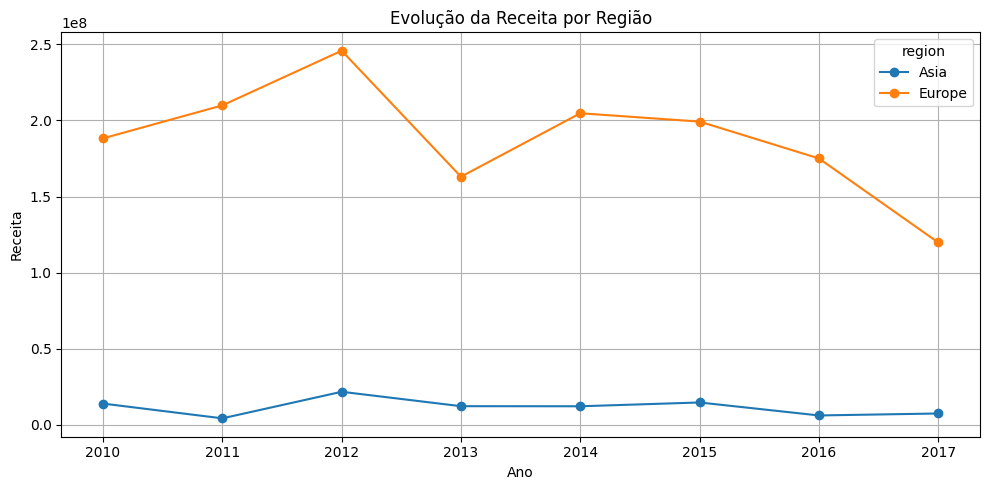

In [106]:
sales_region_year.plot(
    figsize=(10,5),
    marker="o"
)

plt.title("Evolução da Receita por Região")
plt.xlabel("Ano")
plt.ylabel("Receita")

plt.grid(True)

plt.tight_layout()
plt.show()

*Ao analisar a evolução da receita por região, observei que a Europa concentrou o maior faturamento em todos os anos analisados, mantendo uma participação significativamente superior à da Ásia. Ambas as regiões apresentaram oscilações ao longo do período, com destaque para o pico de receita em 2012. Nos anos seguintes, houve uma redução gradual do faturamento, especialmente em 2017, que registrou os menores valores da série.*

*3.9.3 Dinâmica das vendas por país*

In [69]:
top5_countries = (
    df.dropna(subset=["name"])
      .groupby("name")["Revenue"]
      .sum()
      .nlargest(5)
      .index
)

top5_countries

Index(['Czech Republic', 'Ukraine', 'Bosnia and Herzegovina', 'Macedonia',
       'San Marino'],
      dtype='object', name='name')

In [107]:
sales_country_year = (
    df[df["name"].isin(top5_countries)]
      .groupby(["Year", "name"])["Revenue"]
      .sum()
      .unstack()
)

sales_country_year

name,Bosnia and Herzegovina,Czech Republic,Macedonia,San Marino,Ukraine
Year,,,,,
2010,1331049.52,8110413.30,2287760.92,2387947.07,3194980.65
2011,2520932.36,15639309.03,NaN,1249469.12,8946152.38
2012,20506108.34,2217746.82,2681494.87,9356740.99,13994664.31
2013,4399195.84,1419947.10,2848802.16,4935779.21,345008.95
2014,397495.31,14761657.41,6793562.66,7143329.27,8028817.86
2015,17905347.83,6911639.34,16448519.15,6887135.47,5631454.86
2016,3057379.29,1775727.68,5257799.87,9500466.98,5764026.00
2017,NaN,2707491.46,12904145.62,6422840.37,7347212.53


In [ ]:
import matplotlib.pyplot as plt

sales_country_year.plot(
    figsize=(13,6),
    marker="o"
)

plt.title("Evolução da Receita dos 5 Países com Maior Faturamento")
plt.xlabel("Ano")
plt.ylabel("Receita")

plt.grid(True)

plt.tight_layout()
plt.show()

*Ao analisar a evolução da receita dos cinco países com maior faturamento, observei que os valores oscilaram ao longo dos anos, sem uma tendência contínua de crescimento ou queda para todos os países. Essa análise permite comparar o comportamento dos principais mercados ao longo do tempo e identificar possíveis variações no desempenho por país.*

*3.9.4 Vendas por dia da semana*

In [108]:
df["Day of Week"] = df["Order Date"].dt.day_name()

In [111]:
sales_weekday = (
    df.groupby("Day of Week")["Revenue"]
      .sum()
      .reindex([
          "Monday",
          "Tuesday",
          "Wednesday",
          "Thursday",
          "Friday",
          "Saturday",
          "Sunday"
      ])
)

sales_weekday

,Revenue
Day of Week,
Monday,2.754685e+08
Tuesday,2.135239e+08
Wednesday,2.612157e+08
Thursday,2.149222e+08
Friday,2.638070e+08
Saturday,2.336411e+08
Sunday,2.395510e+08


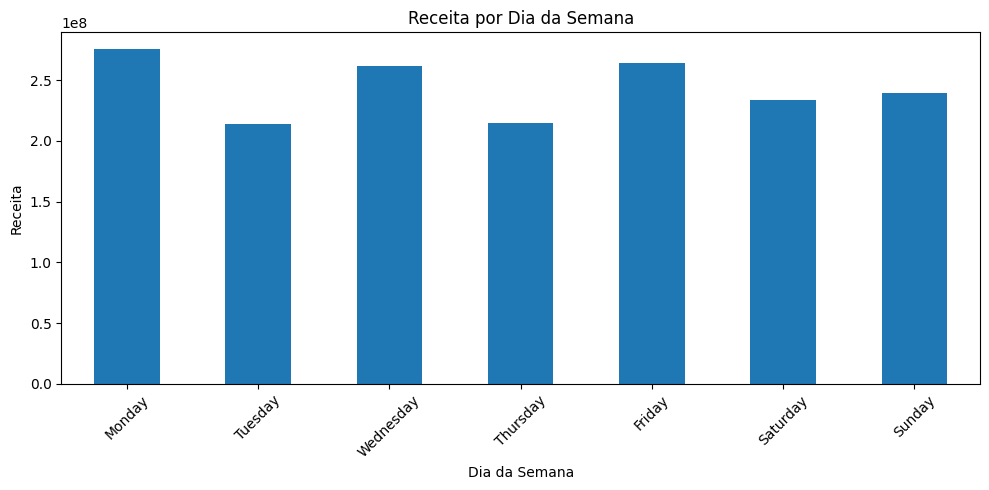

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sales_weekday.plot(kind="bar")

plt.title("Receita por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Receita")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

*Ao analisar a receita por dia da semana, observei que as vendas se distribuíram de forma equilibrada ao longo da semana. A segunda-feira apresentou o maior faturamento, seguida pela sexta-feira e pela quarta-feira, enquanto terça-feira e quinta-feira registraram as menores receitas. Apesar dessas diferenças, não foi possível identificar um padrão de sazonalidade significativo, indicando que as vendas permaneceram bem distribuídas entre os dias da semana.*

*Com base nos resultados obtidos, não é possível afirmar que exista sazonalidade para uma categoria específica de produto. Para confirmar essa hipótese, seria necessária uma análise mais detalhada das vendas por categoria ao longo do tempo.*

***Conclusão Final***

*Neste projeto foram realizadas as etapas de limpeza, tratamento, análise e visualização dos dados de vendas de uma empresa com atuação global. Durante a preparação dos dados, foram tratados valores ausentes, corrigidas inconsistências nas categorias e realizados ajustes nos tipos de dados para garantir maior confiabilidade nas análises.*

*A análise exploratória mostrou que a categoria Office Supplies apresentou o maior faturamento, maior custo e maior volume de unidades vendidas, enquanto Cosmetics se destacou entre as categorias mais lucrativas. Esses resultados mostram que vender mais nem sempre significa gerar mais lucro, reforçando a importância de analisar diferentes indicadores em conjunto.*

*Geograficamente, a Europa concentrou a maior parte da receita, custos, lucro e unidades vendidas da empresa, superando significativamente a Ásia durante o período analisado. Também foram observadas diferenças entre os países com maior faturamento, maior lucratividade e maior volume de vendas, mostrando que cada mercado pode apresentar comportamentos distintos.*

*Na comparação entre os canais de vendas, os resultados mostraram desempenhos semelhantes, com uma leve vantagem para o canal Offline em receita, custo, lucro e quantidade de unidades vendidas. Em relação à logística, o tempo médio de envio foi de aproximadamente 24,78 dias, sem evidências de uma relação clara entre o prazo de envio e a lucratividade dos pedidos.*

*Por fim, a análise temporal revelou oscilações na receita ao longo dos anos, com maior faturamento em 2012, além de variações por categoria, país e região. A análise por dia da semana mostrou uma distribuição equilibrada das vendas, sem indícios de sazonalidade significativa. De modo geral, o projeto demonstrou como a análise exploratória e a visualização de dados podem gerar insights relevantes e apoiar a tomada de decisões com base em dados.*